# Titanic Passenger Data: Cleaning & Quality Audit

**Objective.** Turn the raw Kaggle Titanic training file into a validated, analysis-ready dataset, with every cleaning decision documented, justified and tested.

**Skills demonstrated:** data profiling and quality auditing · missing-value imputation strategy · duplicate detection · schema validation · feature derivation · unit testing · reproducible, documented analysis (Python, pandas, matplotlib).


**Input**  `train.csv` (891 passengers, 12 columns) 
**Output**  `train_cleaned.csv` (891 passengers, 15 columns) 

### Key results

- **0** exact duplicate rows or duplicate passenger IDs found
- **179** missing values in `Age` (177) and `Embarked` (2) resolved, with the imputed ages flagged in a new `age_imputed` column
- **687** missing `Cabin` values deliberately kept as missing (77% of rows). Two derived columns, `has_cabin` and `deck`, make the information usable.
- Automated validation rules enforced on the output, plus unit tests for each cleaning rule

### Contents

1. Setup
2. Data dictionary
3. Data quality audit (missing values and duplicates)
4. Cleaning functions
5. Cleaning decisions
6. Run the pipeline
7. Validation: before vs after
8. Example insights from the cleaned data
9. Export
10. Unit tests
11. Limitations and next steps

**To reproduce:** place `train.csv` next to this notebook, install `pandas`, `numpy`, `matplotlib` (optional: `duckdb`), then choose *Restart & Run All*.

## 1. Setup

In [1]:
from __future__ import annotations

import logging
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s", force=True)
logger = logging.getLogger("titanic_cleaning")

pd.set_option("display.max_columns", 30)
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.axisbelow": True,
})
COLORS = {"primary": "#2F5D8A", "accent": "#D9822B", "muted": "#9AA5B1"}

RAW_PATH = Path("train.csv")
CLEAN_PATH = Path("train_cleaned.csv")

In [2]:
RAW_COLUMNS = [
    "PassengerId", "Survived", "Pclass", "Name", "Sex", "Age",
    "SibSp", "Parch", "Ticket", "Fare", "Cabin", "Embarked",
]

COLUMN_NAMES = {
    "PassengerId": "passenger_id",
    "Survived": "survived",
    "Pclass": "passenger_class",
    "Name": "name",
    "Sex": "sex",
    "Age": "age",
    "SibSp": "siblings_spouses",
    "Parch": "parents_children",
    "Ticket": "ticket",
    "Fare": "fare",
    "Cabin": "cabin",
    "Embarked": "embarked",
}

PORTS = {"S": "Southampton", "C": "Cherbourg", "Q": "Queenstown"}

SEX_LABELS = {"female": "Female", "male": "Male"}

UNKNOWN_DECK = "Unknown"

## 2. Data dictionary

**Source columns**

| Column | Description |
|---|---|
| `PassengerId` | Unique passenger identifier |
| `Survived` | Survival outcome (0 = no, 1 = yes) |
| `Pclass` | Ticket class (1 = upper, 2 = middle, 3 = lower) |
| `Name` | Passenger name, including title |
| `Sex` | Sex as recorded (`male` / `female`) |
| `Age` | Age in years (fractional for infants) |
| `SibSp` | Number of siblings or spouses aboard |
| `Parch` | Number of parents or children aboard |
| `Ticket` | Ticket number |
| `Fare` | Fare paid |
| `Cabin` | Cabin number |
| `Embarked` | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

**Columns added by this pipeline:** `age_imputed` (True if the age was filled in), `has_cabin` (True if a cabin was recorded), `deck` (first letter of the cabin, or `Unknown`).

## 3. Data quality audit

In [3]:
def audit_quality(df: pd.DataFrame, id_col: str) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return ``(missing, duplicates)`` summary tables for a DataFrame.

    ``missing`` lists only columns with missing values, worst first.
    ``duplicates`` reports row- and ID-level duplicate checks with an OK/Review status.
    """
    n_rows = len(df)
    missing = (
        pd.DataFrame({"missing": df.isna().sum()})
        .assign(missing_pct=lambda t: (t["missing"] / n_rows * 100).round(1))
        .query("missing > 0")
        .sort_values("missing", ascending=False)
    )
    counts = {
        "Exact duplicate rows": int(df.duplicated().sum()),
        f"Duplicate {id_col} values": int(df[id_col].duplicated().sum()),
        "Rows identical apart from the ID": int(df.drop(columns=id_col).duplicated().sum()),
    }
    duplicates = pd.DataFrame({"count": counts}).rename_axis("check").reset_index()
    duplicates["status"] = np.where(duplicates["count"] == 0, "OK", "Review")
    return missing, duplicates

In [4]:
raw = pd.read_csv(RAW_PATH)
print(f"Raw data: {raw.shape[0]} rows x {raw.shape[1]} columns")
raw.head()

Raw data: 891 rows x 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3.1 Missing values

In [5]:
raw_missing, raw_duplicates = audit_quality(raw, id_col="PassengerId")
raw_missing

,missing,missing_pct
Cabin,687,77.1
Age,177,19.9
Embarked,2,0.2


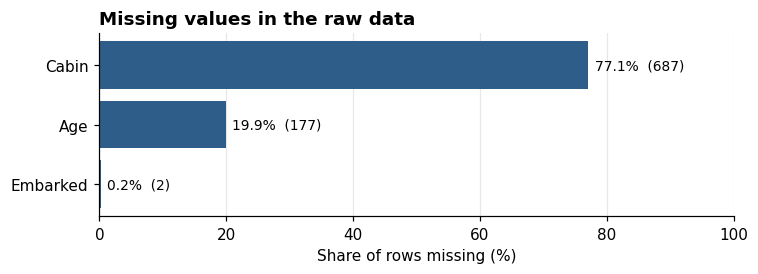

In [6]:
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(raw_missing.index[::-1], raw_missing["missing_pct"][::-1], color=COLORS["primary"])
for y, (pct, n) in enumerate(zip(raw_missing["missing_pct"][::-1], raw_missing["missing"][::-1])):
    ax.text(pct + 1, y, f"{pct}%  ({n})", va="center", fontsize=9)
ax.set_xlim(0, 100)
ax.set_xlabel("Share of rows missing (%)")
ax.set_title("Missing values in the raw data", loc="left", fontweight="bold")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

Three columns have gaps. `Cabin` is missing for most passengers, `Age` for about one in five, and `Embarked` for just two rows. Each needs a different treatment (see section 5).

### 3.2 Duplicates

In [7]:
raw_duplicates

,check,count,status
0,Exact duplicate rows,0,OK
1,Duplicate PassengerId values,0,OK
2,Rows identical apart from the ID,0,OK


In [8]:
shared = int(raw["Ticket"].duplicated(keep=False).sum())
print(f"{shared} passengers share a ticket number with at least one other passenger.")
print("This is expected (families and groups travelled on one ticket), so tickets are not treated as duplicates.")

344 passengers share a ticket number with at least one other passenger.
This is expected (families and groups travelled on one ticket), so tickets are not treated as duplicates.


No exact duplicate rows and no repeated passenger IDs. The pipeline still checks for them on every run, so the same notebook is safe to point at a fresh export. Exact duplicates are dropped; the same ID appearing on *conflicting* rows stops the run with an error rather than guessing which record is right.

### 3.3 Choosing an imputation strategy for `Age`

In [9]:
print(f"Age skew: {raw['Age'].skew():.2f}")
raw["Age"].describe().round(1).to_frame("Age")

Age skew: 0.39


,Age
count,714.0
mean,29.7
std,14.5
min,0.4
25%,20.1
50%,28.0
75%,38.0
max,80.0


In [10]:
raw.groupby(["Pclass", "Sex"])["Age"].median().unstack().rename_axis(columns=None)

,female,male
Pclass,,
1,35.0,40.0
2,28.0,30.0
3,21.5,25.0


Age is mildly right-skewed, and the median age drops clearly from 1st to 3rd class. A single global mean would make third-class passengers too old, so missing ages are filled with the **median of the passenger's class and sex group**, and an `age_imputed` flag records which rows were filled.

## 4. Cleaning functions

### Saving and validation

In [11]:
def save_clean(df: pd.DataFrame, path: str | Path) -> Path:
    """Write the cleaned frame to CSV (parent folders are created)."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_csv(path, index=False)
    logger.info("Saved cleaned data to %s", path)
    return path


def validate_raw(df: pd.DataFrame) -> None:
    """Fail fast if the input does not look like the Titanic training set."""
    missing = [c for c in RAW_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Raw data is missing required columns: {missing}")
    if not df["Survived"].isin([0, 1]).all():
        raise ValueError("Survived must only contain 0 or 1")
    if not df["Pclass"].isin([1, 2, 3]).all():
        raise ValueError("Pclass must only contain 1, 2 or 3")


def validate_clean(df: pd.DataFrame) -> None:
    """Assert the post-conditions the rest of the project relies on."""
    problems: list[str] = []

    for col in ("passenger_id", "survived", "passenger_class", "sex",
                "age", "fare", "embarked", "deck"):
        n_null = int(df[col].isna().sum())
        if n_null:
            problems.append(f"{col} still has {n_null} missing values")

    if not df["passenger_id"].is_unique:
        problems.append("passenger_id is not unique")
    if not df["age"].between(0, 120).all():
        problems.append("age outside [0, 120]")
    if (df["fare"] < 0).any():
        problems.append("negative fares present")
    if not set(df["sex"].unique()) <= set(SEX_LABELS.values()):
        problems.append("unexpected values in sex")
    if not set(df["embarked"].astype(str).unique()) <= set(PORTS.values()):
        problems.append("unexpected values in embarked")
    if not set(df["survived"].unique()) <= {0, 1}:
        problems.append("survived is not binary")
    if (df["has_cabin"] != df["cabin"].notna()).any():
        problems.append("has_cabin is inconsistent with cabin")

    if problems:
        raise ValueError("Cleaned data failed validation: " + "; ".join(problems))

### Cleaning steps

In [12]:
def _strip_text(df: pd.DataFrame) -> pd.DataFrame:
    """Trim stray whitespace and turn blank strings into real missing values."""
    for col in df.select_dtypes(include=["object", "string"]).columns:
        df[col] = df[col].str.strip().replace("", np.nan)
    return df


def _clean_sex(df: pd.DataFrame) -> pd.DataFrame:
    df["Sex"] = df["Sex"].str.lower().map(SEX_LABELS)
    if df["Sex"].isna().any():
        raise ValueError("Unrecognised values found in Sex")
    return df


def _clean_embarked(df: pd.DataFrame) -> pd.DataFrame:
    """Impute missing ports with the mode, *then* expand codes to names.

    Imputing before the mapping keeps the mode computed on a single, consistent
    vocabulary and means the mapping never sees a missing value.
    """
    n_missing = int(df["Embarked"].isna().sum())
    if n_missing:
        mode = df["Embarked"].mode().iloc[0]
        df["Embarked"] = df["Embarked"].fillna(mode)
        logger.info("Embarked: imputed %d missing value(s) with mode '%s'",
                    n_missing, mode)
    df["Embarked"] = df["Embarked"].map(PORTS)
    if df["Embarked"].isna().any():
        raise ValueError("Unrecognised port codes found in Embarked")
    return df


def _clean_age(df: pd.DataFrame) -> pd.DataFrame:
    """Impute Age with the median of the passenger's (Pclass, Sex) group.

    * The median is robust to the right-skew in Age.
    * Age differs strongly by class, so a group median is a better guess than
      a single global statistic.
    * ``age_imputed`` keeps the imputation visible to downstream models.
    """
    df["age_imputed"] = df["Age"].isna()
    n_missing = int(df["age_imputed"].sum())
    if n_missing:
        group_median = df.groupby(["Pclass", "Sex"])["Age"].transform("median")
        df["Age"] = df["Age"].fillna(group_median).fillna(df["Age"].median())
        logger.info("Age: imputed %d missing value(s) with the (Pclass, Sex) median",
                    n_missing)
    return df


def _clean_cabin(df: pd.DataFrame) -> pd.DataFrame:
    """Keep Cabin as a true missing value and derive explicit features.

    Filling with a sentinel string such as ``'NaN'`` hides missingness from
    ``isna()``, ``COUNT(cabin)`` and similar tools, so it is avoided here.
    """
    df["has_cabin"] = df["Cabin"].notna()
    df["deck"] = df["Cabin"].str[0].str.upper().fillna(UNKNOWN_DECK)
    logger.info("Cabin: %d of %d passengers have no cabin recorded",
                int((~df["has_cabin"]).sum()), len(df))
    return df


def _set_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    df["Survived"] = df["Survived"].astype("int8")  # stays numeric: .mean() = survival rate
    df["Pclass"] = pd.Categorical(df["Pclass"], categories=[1, 2, 3], ordered=True)
    for col in ("Sex", "Embarked", "deck"):
        df[col] = df[col].astype("category")
    return df

### Pipeline

In [13]:
def clean(raw: pd.DataFrame) -> pd.DataFrame:
    """Return a cleaned copy of the raw Titanic training data."""
    validate_raw(raw)
    df = raw.copy()

    n_dupes = int(df.duplicated().sum())
    if n_dupes:
        df = df.drop_duplicates()
        logger.warning("Dropped %d exact duplicate row(s)", n_dupes)
    if df["PassengerId"].duplicated().any():
        raise ValueError("PassengerId is duplicated across conflicting rows")

    df = _strip_text(df)
    df = _clean_sex(df)
    df = _clean_embarked(df)
    df = _clean_age(df)
    df = _clean_cabin(df)  
    df = _set_dtypes(df)

    n_zero_fare = int((df["Fare"] == 0).sum())
    if n_zero_fare:
        logger.info("Fare: %d passenger(s) have a fare of 0 (left unchanged)", n_zero_fare)

    df = df.rename(columns=COLUMN_NAMES)
    df = df.reset_index(drop=True)

    validate_clean(df)
    return df

## 5. Cleaning decisions

| Issue | Decision | Why |
|---|---|---|
| `Age` missing (177) | Fill with the median of the passenger's (class, sex) group; add `age_imputed` flag | Median is robust to skew; class and sex explain much of the age variation; the flag lets later models treat imputed ages differently |
| `Cabin` missing (687) | Keep as missing; add `has_cabin` and `deck` | 77% missing is too much to fill honestly. A text placeholder would hide the gap from `isna()` and SQL `NULL` logic |
| `Embarked` missing (2) | Fill with the most common port, then expand `S/C/Q` to port names | Only 2 rows, so the effect of the guess is negligible |
| `Sex` | Normalise to `Male` / `Female` | Consistent labels, and unexpected values raise an error |
| `Survived` | Store as `int8` | Stays numeric, so `.mean()` gives the survival rate directly |
| `Pclass` | Ordered category 1 < 2 < 3 | Encodes that classes have an order |
| `Fare == 0` (15 rows) | Left unchanged and logged | Could be crew, staff or data errors, and the data cannot tell which |
| Column names | Convert to `snake_case` | Consistent, SQL-friendly names |
| Duplicates | Drop exact duplicates; fail on conflicting IDs | Safe automatic fix where it is unambiguous |

## 6. Run the pipeline

In [14]:
df = clean(raw)
df.head()

INFO | Embarked: imputed 2 missing value(s) with mode 'S'
INFO | Age: imputed 177 missing value(s) with the (Pclass, Sex) median
INFO | Cabin: 687 of 891 passengers have no cabin recorded
INFO | Fare: 15 passenger(s) have a fare of 0 (left unchanged)


,passenger_id,survived,passenger_class,name,sex,age,siblings_spouses,parents_children,ticket,fare,cabin,embarked,age_imputed,has_cabin,deck
0,1,0,3,"Braund, Mr. Owen Harris",Male,22.0,1,0,A/5 21171,7.2500,NaN,Southampton,False,False,Unknown
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Female,38.0,1,0,PC 17599,71.2833,C85,Cherbourg,False,True,C
2,3,1,3,"Heikkinen, Miss. Laina",Female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,Southampton,False,False,Unknown
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Female,35.0,1,0,113803,53.1000,C123,Southampton,False,True,C
4,5,0,3,"Allen, Mr. William Henry",Male,35.0,0,0,373450,8.0500,NaN,Southampton,False,False,Unknown


## 7. Validation: before vs after

In [15]:
clean_missing, clean_duplicates = audit_quality(df, id_col="passenger_id")

scorecard = pd.DataFrame({
    "Raw": {
        "Rows": len(raw),
        "Columns": raw.shape[1],
        "Missing values (all columns)": int(raw.isna().sum().sum()),
        "Missing values (excluding Cabin)": int(raw.drop(columns="Cabin").isna().sum().sum()),
        "Exact duplicate rows": int(raw_duplicates.set_index("check").loc["Exact duplicate rows", "count"]),
    },
    "Cleaned": {
        "Rows": len(df),
        "Columns": df.shape[1],
        "Missing values (all columns)": int(df.isna().sum().sum()),
        "Missing values (excluding Cabin)": int(df.drop(columns="cabin").isna().sum().sum()),
        "Exact duplicate rows": int(clean_duplicates.set_index("check").loc["Exact duplicate rows", "count"]),
    },
})
scorecard

,Raw,Cleaned
Rows,891,891
Columns,12,15
Missing values (all columns),866,687
Missing values (excluding Cabin),179,0
Exact duplicate rows,0,0


In [16]:
# clean() already runs validate_clean(); these assertions make the guarantees explicit.
assert len(df) == len(raw)
assert df.drop(columns="cabin").isna().sum().sum() == 0
assert (clean_duplicates["status"] == "OK").all()
assert clean_missing.index.tolist() == ["cabin"]  # the only remaining gap is intentional
clean_missing

,missing,missing_pct
cabin,687,77.1


In [17]:
df.dtypes.astype(str).to_frame("dtype").T

,passenger_id,survived,passenger_class,name,sex,age,siblings_spouses,parents_children,ticket,fare,cabin,embarked,age_imputed,has_cabin,deck
dtype,int64,int8,category,object,category,float64,int64,int64,object,float64,object,category,bool,bool,category


Age was imputed for 177 passengers. The check below confirms that filling those gaps did not distort the age distribution.

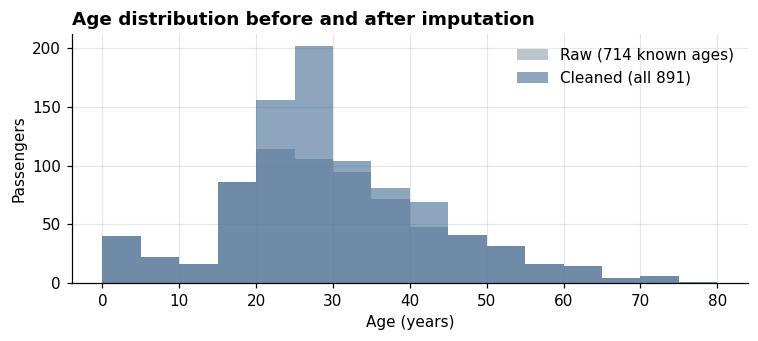

In [18]:
fig, ax = plt.subplots(figsize=(7, 3.2))
bins = np.arange(0, 85, 5)
ax.hist(raw["Age"].dropna(), bins=bins, alpha=0.65, color=COLORS["muted"], label="Raw (714 known ages)")
ax.hist(df["age"], bins=bins, alpha=0.55, color=COLORS["primary"], label="Cleaned (all 891)")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Passengers")
ax.set_title("Age distribution before and after imputation", loc="left", fontweight="bold")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

The overall shape is preserved. Imputed values pile up near the group medians (about 21 to 40 years), which is the expected cost of median imputation.

## 8. Example insights from the cleaned data

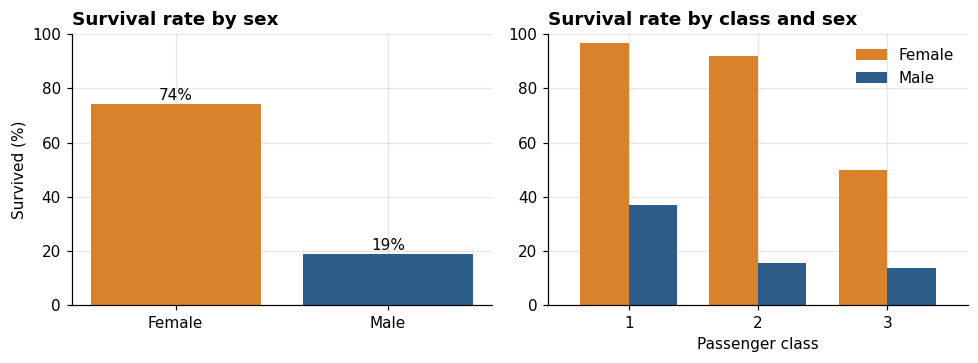

In [19]:
by_sex = df.groupby("sex", observed=True)["survived"].mean().mul(100)
by_class_sex = (df.groupby(["passenger_class", "sex"], observed=True)["survived"]
                  .mean().mul(100).unstack())

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))

axes[0].bar(by_sex.index.astype(str), by_sex.values, color=[COLORS["accent"], COLORS["primary"]])
axes[0].set_title("Survival rate by sex", loc="left", fontweight="bold")
axes[0].set_ylabel("Survived (%)")
for i, v in enumerate(by_sex.values):
    axes[0].text(i, v + 1.5, f"{v:.0f}%", ha="center")
axes[0].set_ylim(0, 100)

by_class_sex.plot.bar(ax=axes[1], color=[COLORS["accent"], COLORS["primary"]], rot=0, width=0.75)
axes[1].set_title("Survival rate by class and sex", loc="left", fontweight="bold")
axes[1].set_xlabel("Passenger class")
axes[1].set_ylabel("")
axes[1].set_ylim(0, 100)
axes[1].legend(title=None, frameon=False)

plt.tight_layout()
plt.show()

Women survived at nearly four times the rate of men, and survival falls steadily from 1st to 3rd class for both sexes. Because `survived` is stored as a number, these rates come straight from `.mean()`.

The same style of question in SQL (requires `pip install duckdb`). DuckDB reads the pandas variable `df` directly.

In [20]:
try:
    import duckdb
except ImportError:
    print("duckdb not installed - skipping the SQL example (pip install duckdb)")
else:
    query = """
        SELECT embarked, COUNT(*) AS passengers
        FROM df
        WHERE cabin LIKE 'B%'
        GROUP BY embarked
        ORDER BY passengers DESC
    """
    display(duckdb.sql(query).df())

,embarked,passengers
0,Southampton,25
1,Cherbourg,22


## 9. Export

In [21]:
save_clean(df, CLEAN_PATH)

INFO | Saved cleaned data to train_cleaned.csv


PosixPath('train_cleaned.csv')

## 10. Unit tests

Small synthetic cases that check each cleaning rule, the duplicate handling and the audit function. All should pass after running the cells above.

In [22]:
import unittest

import numpy as np


def make_raw(**overrides) -> pd.DataFrame:
    """A tiny valid raw frame; column overrides replace whole columns."""
    data = {
        "PassengerId": [1, 2, 3, 4],
        "Survived": [0, 1, 1, 0],
        "Pclass": [3, 1, 3, 1],
        "Name": ["A, Mr. X", "B, Mrs. Y", "C, Miss. Z", "D, Mr. W"],
        "Sex": ["male", "female", "female", "male"],
        "Age": [22.0, 38.0, np.nan, np.nan],
        "SibSp": [1, 1, 0, 0],
        "Parch": [0, 0, 0, 0],
        "Ticket": ["T1", "T2", "T3", "T4"],
        "Fare": [7.25, 71.28, 7.92, 51.86],
        "Cabin": [np.nan, "C85", np.nan, "E46"],
        "Embarked": ["S", "C", "S", np.nan],
    }
    data.update(overrides)
    return pd.DataFrame(data)


class CleanTests(unittest.TestCase):
    def test_input_is_not_mutated(self):
        raw = make_raw()
        snapshot = raw.copy(deep=True)
        clean(raw)
        pd.testing.assert_frame_equal(raw, snapshot)

    def test_only_cabin_has_missing_values(self):
        out = clean(make_raw())
        self.assertEqual(out.isna().sum()[lambda s: s > 0].index.tolist(), ["cabin"])

    def test_cabin_features(self):
        out = clean(make_raw())
        self.assertEqual(out["deck"].astype(str).tolist(), ["Unknown", "C", "Unknown", "E"])
        self.assertEqual(out["has_cabin"].tolist(), [False, True, False, True])

    def test_age_imputation_is_flagged(self):
        out = clean(make_raw())
        self.assertEqual(out["age_imputed"].tolist(), [False, False, True, True])
        self.assertEqual(out.loc[2:3, "age"].tolist(), [30.0, 30.0])

    def test_embarked_mode_then_expanded(self):
        out = clean(make_raw())
        self.assertEqual(out["embarked"].astype(str).tolist(),
                         ["Southampton", "Cherbourg", "Southampton", "Southampton"])

    def test_sex_whitespace_and_case(self):
        out = clean(make_raw(Sex=[" MALE", "Female ", "female", "male"]))
        self.assertEqual(out["sex"].astype(str).tolist(), ["Male", "Female", "Female", "Male"])

    def test_exact_duplicates_are_dropped(self):
        raw = pd.concat([make_raw(), make_raw().iloc[[0]]], ignore_index=True)
        self.assertEqual(len(clean(raw)), 4)

    def test_conflicting_duplicate_ids_are_rejected(self):
        raw = make_raw(PassengerId=[1, 1, 3, 4])
        with self.assertRaises(ValueError):
            clean(raw)

    def test_bad_inputs_are_rejected(self):
        with self.assertRaises(ValueError):
            validate_raw(make_raw().drop(columns=["Fare"]))
        with self.assertRaises(ValueError):
            validate_raw(make_raw(Survived=[0, 1, 2, 0]))
        with self.assertRaises(ValueError):
            clean(make_raw(Embarked=["S", "C", "X", "S"]))

    def test_audit_detects_missing_and_duplicates(self):
        raw = make_raw()
        missing, dups = audit_quality(pd.concat([raw, raw.iloc[[0]]], ignore_index=True), "PassengerId")
        counts = dict(zip(dups["check"], dups["count"]))
        self.assertEqual(counts["Exact duplicate rows"], 1)
        self.assertEqual(counts["Duplicate PassengerId values"], 1)
        self.assertEqual(missing.index[0], "Cabin")
        self.assertEqual(missing.loc["Age", "missing"], 2)

    def test_audit_is_clean_after_cleaning(self):
        missing, dups = audit_quality(clean(make_raw()), "passenger_id")
        self.assertEqual(missing.index.tolist(), ["cabin"])
        self.assertTrue((dups["status"] == "OK").all())


logging.disable(logging.CRITICAL)  # keep test output readable
suite = unittest.defaultTestLoader.loadTestsFromTestCase(CleanTests)
result = unittest.TextTestRunner(verbosity=1).run(suite)
logging.disable(logging.NOTSET)
assert result.testsRun > 0 and result.wasSuccessful(), "Some tests failed"

...........
----------------------------------------------------------------------
Ran 11 tests in 0.060s

OK


## 11. Limitations and next steps

- **Imputed ages are estimates.** Group medians are reasonable for cleaning, but a model-based approach (for example using the title in `name`, such as *Master* for boys) could recover more detail. Use `age_imputed` to test how sensitive any results are.
- **Zero fares were not changed.** The 15 passengers with `fare == 0` need domain knowledge or an outside source to resolve.
- **`cabin` is mostly empty.** `deck` is only reliable for the 23% of passengers with a recorded cabin.
- **Next steps:** extract passenger titles from `name`, bin ages and fares for modelling, and add a modelling notebook that uses `age_imputed` and `has_cabin` as features.